# PyTorch Neural Network Exercise: Two Moons Classification

In this notebook, you will build a small feed-forward neural network that learns to separate two curved classes. The Two Moons dataset is useful for this exercise because a straight line cannot separate the classes well. A neural network must learn a nonlinear decision boundary.

## Learning objectives

By the end of the exercise, you should be able to:

- describe the role of features and class labels
- prepare NumPy data for PyTorch
- define a neural network with `nn.Module`
- explain logits, loss, gradients, and parameter updates
- train a classifier using a complete PyTorch training loop
- evaluate generalization on unseen test data
- visualize the decision boundary learned by the model
- compare two network architectures

## How to complete the notebook

Run the cells in order. In the student version, each missing expression is written as `...`. Replace the ellipsis with the complete right-hand-side expression. The variable name and surrounding program structure are already provided.

All explanations and hints appear in markdown cells. Code cells contain only Python.

## 1. Import the libraries

This exercise uses NumPy for numerical arrays, Matplotlib for visualization, scikit-learn for generating and preparing the dataset, and PyTorch for the neural network.

The random seeds make the generated dataset and initial model weights reproducible. Reproducibility is useful in a teaching exercise because repeated runs are more likely to produce comparable results.

The import code is provided in full. Run the cell and confirm that PyTorch loads successfully.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn

np.random.seed(7)
torch.manual_seed(7)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.7.0


## 2. Generate the dataset

The Two Moons dataset contains two input features and one binary class label. Each row of `X` represents one observation. The matching value in `y` identifies whether that observation belongs to class `0` or class `1`.

The `noise` value makes the problem more realistic by adding variation to the moon shapes. The `random_state` value makes the generated sample reproducible.

This code is provided because dataset generation is setup work rather than the main neural-network learning objective. After running the cell, verify that `X` has 500 rows and two columns.


In [2]:
X, y = make_moons(
    n_samples=500,
    noise=0.20,
    random_state=7
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFirst five feature rows:")
print(X[:5])
print("\nFirst five labels:")
print(y[:5])

X shape: (500, 2)
y shape: (500,)

First five feature rows:
[[ 0.54808589 -0.15567719]
 [ 0.88337053  0.22511664]
 [ 1.37734174 -0.25054257]
 [ 0.9169997   0.67145932]
 [ 1.98126362 -0.11721651]]

First five labels:
[1 0 1 0 1]


## 3. Visualize the dataset

Before training a model, inspect the relationship between the two features. Each point represents one sample. Its horizontal and vertical positions come from the two feature values, while its color represents the class label.

You should see two curved groups that partially wrap around each other. This shape explains why a purely linear classifier would struggle: the boundary between the classes needs to bend.

Complete the expression assigned to `scatter`.

### Hint

**Core API:** `plt.scatter(...)`

Use column `0` of `X` for the horizontal coordinates, column `1` for the vertical coordinates, and `y` for the colors.

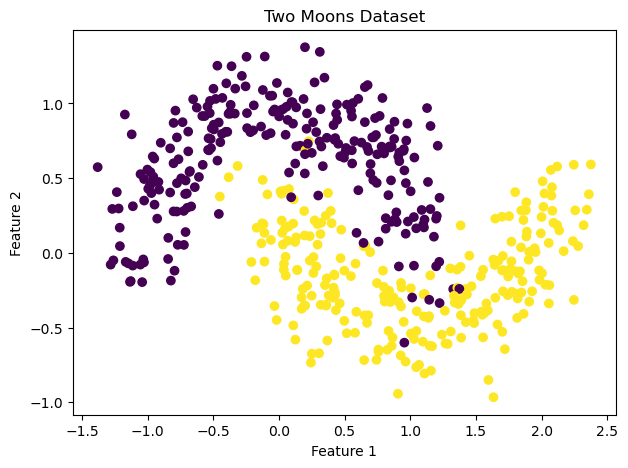

In [3]:
plt.figure(figsize=(7, 5))

scatter = plt.scatter(X[:, 0], X[:, 1], c=y)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Two Moons Dataset")
plt.show()

## 4. Split the dataset

A model should be evaluated on observations that were not used to update its parameters. The training set is used to learn the weights. The test set is held back until evaluation.

This notebook reserves 20% of the observations for testing. The `stratify` argument keeps the proportion of class `0` and class `1` similar in both subsets. The split code is provided because the focus of the exercise is the neural network itself.

After running the cell, confirm that the training set contains 400 observations and the test set contains 100.

### Hint

**Core API:** `train_test_split(...)`

The returned arrays remain NumPy arrays at this stage.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=7,stratify=y)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 400
Test samples: 100


## 5. Standardize the features

Neural networks generally train more reliably when numerical inputs are on comparable scales. Standardization subtracts the training mean and divides by the training standard deviation.

The scaler must learn its statistics from the training data only. Allowing the test set to influence those statistics would leak information from the evaluation data into the training process.

Complete the expressions assigned to `X_train` and `X_test`. The same fitted scaler must be used for both arrays.

### Hint

**Core APIs:** `fit_transform(...)` and `transform(...)`

Fit and transform the training set in one operation. Transform the test set without fitting again.

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training mean:", X_train.mean(axis=0))
print("Training standard deviation:", X_train.std(axis=0))

Training mean: [ 1.54321000e-16 -1.40998324e-16]
Training standard deviation: [1. 1.]


## 6. Convert the arrays to PyTorch tensors

PyTorch layers operate on tensors rather than NumPy arrays. The feature tensors should use floating-point values because the network performs continuous numerical calculations. The label tensors should use integer class indexes because `CrossEntropyLoss` expects class identifiers.

The first dimension still represents samples. The second dimension of each feature tensor should contain the two input features.

Complete all four tensor expressions.

### Hint

**Core API:** `torch.tensor(...)`

Use `torch.float32` for feature tensors and `torch.long` for label tensors.

In [7]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("Training features:", X_train_tensor.shape, X_train_tensor.dtype)
print("Training labels:", y_train_tensor.shape, y_train_tensor.dtype)
print("Test features:", X_test_tensor.shape, X_test_tensor.dtype)
print("Test labels:", y_test_tensor.shape, y_test_tensor.dtype)

Training features: torch.Size([400, 2]) torch.float32
Training labels: torch.Size([400]) torch.int64
Test features: torch.Size([100, 2]) torch.float32
Test labels: torch.Size([100]) torch.int64


## 7. Build the neural network

The network receives two input values per sample. It then passes the values through two hidden layers containing 16 neurons each. ReLU activation functions introduce nonlinearity between the linear layers. The final layer produces two output scores, one for each class.

The output values are called **logits**. Do not add a softmax layer here. `CrossEntropyLoss` accepts logits directly and performs the required probability-related calculation internally.

Use the following architecture:

```text
2 inputs
→ Linear(2, 16)
→ ReLU
→ Linear(16, 16)
→ ReLU
→ Linear(16, 2)
```

Complete the expression assigned to `self.network`, then complete the expression assigned to `output` in `forward`.

### Hint

**Core classes:** `nn.Sequential`, `nn.Linear`, and `nn.ReLU`

`nn.Sequential` can store the layers in the exact order shown above. The forward method should pass `x` through the stored network.

In [8]:
class MoonClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        output = self.network(x)
        return output


model = MoonClassifier()
print(model)

MoonClassifier(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)


## 8. Inspect one forward pass

A forward pass sends input values through every layer of the network. At this point, the model has not been trained, so the resulting logits are based on randomly initialized parameters.

Pass the first five training observations through the model. The output should have five rows and two columns. Each row corresponds to one sample, and each column corresponds to one class score.

Complete the expression assigned to `sample_logits`.

### Hint

A PyTorch model is callable. Supply the selected tensor batch inside parentheses after the model variable.

In [9]:
sample_logits = model(X_train_tensor[:5])

print(sample_logits)
print("Output shape:", sample_logits.shape)

tensor([[ 0.0037,  0.1833],
        [-0.0171,  0.1041],
        [-0.0069,  0.1344],
        [-0.0213,  0.1027],
        [-0.0131,  0.1063]], grad_fn=<AddmmBackward0>)
Output shape: torch.Size([5, 2])


## 9. Define the loss function and optimizer

The loss function measures how incorrect the model's logits are relative to the true labels. During training, the goal is to reduce this value.

The optimizer changes the trainable parameters using the gradients calculated during backpropagation. Adam is a commonly used optimizer that adapts the size of its parameter updates.

Use cross-entropy loss and Adam with a learning rate of `0.01`. Complete the expressions assigned to `criterion` and `optimizer`.

### Hint

**Core APIs:** `nn.CrossEntropyLoss()` and `torch.optim.Adam(...)`

The optimizer must receive the model's trainable parameters.

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

## 10. Train the neural network

Training repeats the same sequence for many epochs:

1. place the model in training mode
2. clear gradients left from the previous iteration
3. calculate logits with a forward pass
4. compare the logits with the true labels to calculate loss
5. run backpropagation to calculate gradients
6. let the optimizer update the parameters
7. save the loss and calculate training accuracy

The outer loop, history lists, and progress display are provided. Implement the training stages directly under the `TODO` comments. Unlike the earlier exercises, the individual expressions are not preassigned to variables, so you have more freedom to organize the code inside the loop.

Training uses the full training tensor in each epoch. This is called full-batch gradient descent. For a larger dataset, batches would normally be supplied by a `DataLoader`.

### Hint

Use these core methods during each epoch:

- `model.train()`
- `optimizer.zero_grad()`
- `loss.backward()`
- `optimizer.step()`
- `torch.argmax(...)`

The order of the stages matters.

In [11]:
num_epochs = 300

loss_history = []
accuracy_history = []

for epoch in range(num_epochs):

    model.train()

    # TODO 1: Clear gradients left from the previous epoch.
    optimizer.zero_grad()

    # TODO 2: Run a forward pass with the training features
    # and store the resulting logits.
    logits = model(X_train_tensor)

    # TODO 3: Calculate the loss from the logits
    # and the training labels.
    loss = criterion(logits, y_train_tensor)

    # TODO 4: Backpropagate the loss to calculate gradients.
    loss.backward()

    # TODO 5: Update the model parameters.
    optimizer.step()

    # TODO 6: Store the scalar loss in loss_history.
    loss_history.append(loss.item())

    # TODO 7: Convert the logits into predicted class labels.
    predictions = torch.argmax(logits, dim=1)

    # TODO 8: Calculate the scalar training accuracy
    # and store it in accuracy_history.
    accuracy = ((predictions == y_train_tensor).float().mean().item())

    accuracy_history.append(accuracy)

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Loss: {loss.item():.4f} | "
            f"Training accuracy: {accuracy:.3f}"
        )

Epoch  50 | Loss: 0.2499 | Training accuracy: 0.908
Epoch 100 | Loss: 0.1039 | Training accuracy: 0.960
Epoch 150 | Loss: 0.0936 | Training accuracy: 0.967
Epoch 200 | Loss: 0.0892 | Training accuracy: 0.970
Epoch 250 | Loss: 0.0859 | Training accuracy: 0.978
Epoch 300 | Loss: 0.0826 | Training accuracy: 0.978


## 11. Plot the training loss

The loss history shows how the optimization process progressed. A successful training run should usually show a large early decrease followed by smaller improvements.

The curve does not need to decrease perfectly at every point in every neural-network problem, but the overall direction should move downward. Because this exercise uses the full dataset in every epoch, the curve should be relatively smooth.

Complete the expression assigned to `loss_plot`.

### Hint

**Core API:** `plt.plot(...)`

The values to plot are stored in `loss_history`.

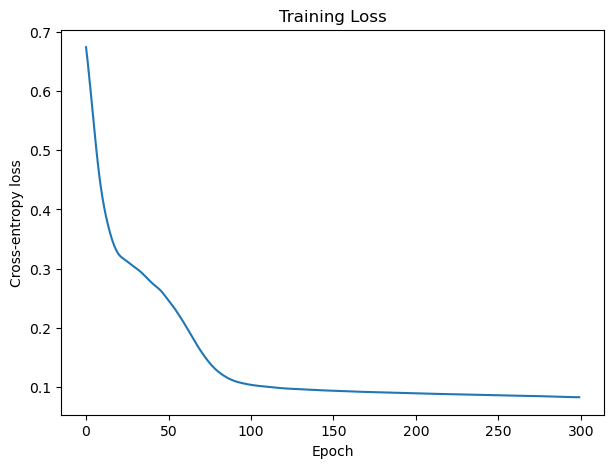

In [12]:
plt.figure(figsize=(7, 5))

loss_plot = plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training Loss")
plt.show()

## 12. Plot the training accuracy

Training accuracy records the proportion of training observations classified correctly after each epoch. It should generally rise as the loss decreases.

Accuracy alone does not reveal whether the model generalizes to new observations. A model can memorize its training set, so the test-set evaluation in the next section remains essential.

Complete the expression assigned to `accuracy_plot`.

### Hint

**Core API:** `plt.plot(...)`

The values to plot are stored in `accuracy_history`.

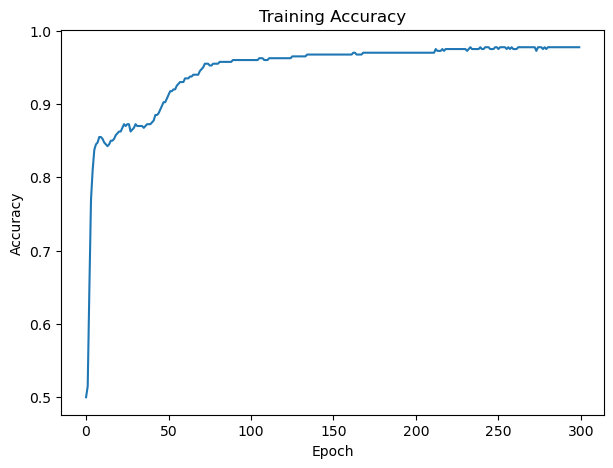

In [13]:
plt.figure(figsize=(7, 5))

accuracy_plot = plt.plot(accuracy_history)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()

## 13. Evaluate the model on the test set

Evaluation measures performance on observations that were not used for parameter updates. First switch the model to evaluation mode. Then disable gradient tracking because evaluation does not require backpropagation.

The model still returns logits. Convert those logits into predicted class indexes, compare them with the true test labels, and calculate the proportion that match.

Complete the expressions assigned to `test_logits`, `test_predictions`, and `test_accuracy`.

### Hint

**Core APIs:** `model.eval()`, `torch.no_grad()`, and `torch.argmax(...)`

Use the same accuracy calculation pattern that was used during training.

In [15]:
model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)

    test_predictions = torch.argmax(test_logits, dim=1)

    test_accuracy = ((test_predictions == y_test_tensor).float().mean().item())

print(f"Test accuracy: {test_accuracy:.3f}")

Test accuracy: 0.990


## 14. Inspect individual predictions

A single accuracy number summarizes the entire test set, but individual predictions make the model's behavior more concrete.

For the first ten test observations, extract the predicted label and the actual label. Tensor elements are still zero-dimensional tensors, so convert each one into a regular Python integer before printing.

Complete the expressions assigned to `predicted_label` and `actual_label`.

### Hint

Use tensor indexing followed by `.item()`.

In [17]:
for index in range(10):

    predicted_label = test_predictions[index].item()
    actual_label = y_test_tensor[index].item()

    print(
        f"Sample {index:2d} | "
        f"Prediction: {predicted_label} | "
        f"Actual: {actual_label}"
    )

Sample  0 | Prediction: 0 | Actual: 0
Sample  1 | Prediction: 0 | Actual: 0
Sample  2 | Prediction: 0 | Actual: 0
Sample  3 | Prediction: 0 | Actual: 0
Sample  4 | Prediction: 0 | Actual: 0
Sample  5 | Prediction: 1 | Actual: 1
Sample  6 | Prediction: 0 | Actual: 0
Sample  7 | Prediction: 1 | Actual: 1
Sample  8 | Prediction: 1 | Actual: 1
Sample  9 | Prediction: 0 | Actual: 0


## 15. Create a prediction grid

A decision-boundary plot requires predictions at many coordinates, not only at the original observations. The code below creates a dense rectangular grid covering the feature space.

Each grid coordinate becomes one row in `grid_points`, and the rows are converted into a floating-point tensor. The grid-generation code is provided because the learning objective is interpreting the model's predictions rather than constructing a mesh manually.

After running the cell, the tensor contains 90,000 coordinate pairs.

In [18]:
x_min = X_train[:, 0].min() - 0.5
x_max = X_train[:, 0].max() + 0.5

y_min = X_train[:, 1].min() - 0.5
y_max = X_train[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

grid_tensor = torch.tensor(
    grid_points,
    dtype=torch.float32
)

print("Grid tensor shape:", grid_tensor.shape)

Grid tensor shape: torch.Size([90000, 2])


## 16. Visualize the prediction grid

Before asking the model to classify the grid, visualize the coordinates that were created in the previous section.

The complete grid contains 90,000 points, so plotting every point would make the figure unnecessarily dense. Display every 100th point to reveal the rectangular grid structure clearly.

Complete the expression assigned to `grid_scatter`.

### Hint

**Core API:** `plt.scatter(...)`

Use every 100th row of `grid_points`. Column `0` contains the horizontal coordinates and column `1` contains the vertical coordinates.


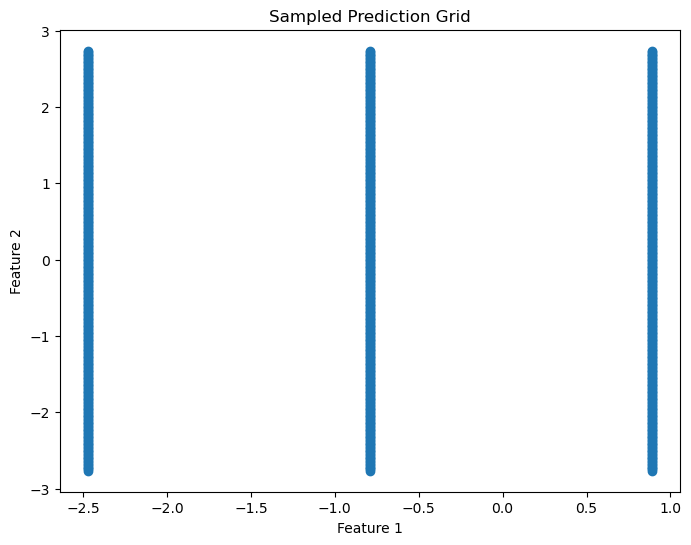

In [19]:
plt.figure(figsize=(8, 6))

grid_scatter = plt.scatter(grid_points[::100, 0],grid_points[::100, 1])

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Sampled Prediction Grid")
plt.show()


## 17. Predict the grid classes

The model must classify every coordinate in the grid. As with test-set evaluation, gradient tracking is unnecessary.

The predicted class indexes initially form a one-dimensional tensor. The provided lines convert the tensor to NumPy and reshape it to match the two-dimensional grid. This shape is required by the contour plot in the next section.

Complete the expressions assigned to `grid_logits` and `grid_predictions`.

### Hint

Pass `grid_tensor` through the trained model, then select the largest logit along the class dimension.

In [20]:
model.eval()

with torch.no_grad():

    grid_logits = model(grid_tensor)
    grid_predictions = torch.argmax(grid_logits,dim=1)

grid_predictions = grid_predictions.numpy()
grid_predictions = grid_predictions.reshape(xx.shape)

print("Prediction grid shape:", grid_predictions.shape)

Prediction grid shape: (300, 300)


## 18. Plot the decision boundary

The background of the graph represents the class predicted at every grid coordinate. The test observations are drawn on top so that the learned regions can be compared with the true classes.

A successful network should learn a curved boundary that follows the two moon shapes. Misclassified points may still appear near overlapping or noisy regions.

Complete the expressions assigned to `boundary` and `points`.

### Hint

**Core APIs:** `plt.contourf(...)` and `plt.scatter(...)`

The contour uses `xx`, `yy`, and `grid_predictions`. The scatter plot uses the two test features and `y_test`.

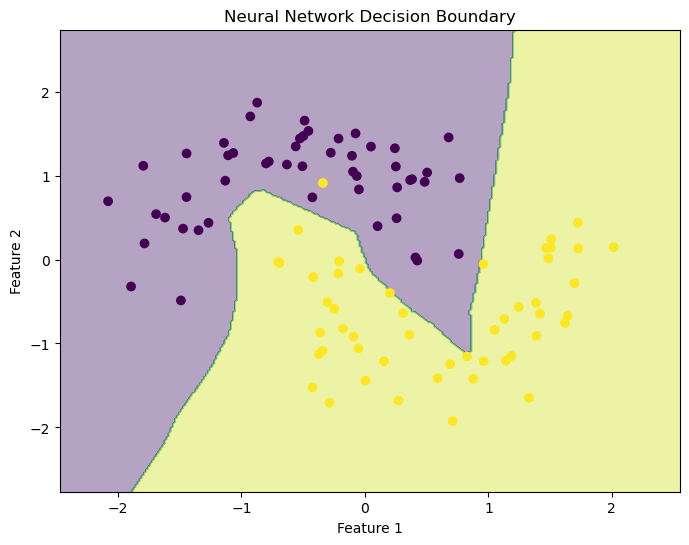

In [21]:
plt.figure(figsize=(8, 6))

boundary = plt.contourf(xx,yy,grid_predictions,alpha=0.4)

points = plt.scatter(X_test[:, 0],X_test[:, 1],c=y_test)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Neural Network Decision Boundary")
plt.show()

## 19. Short-answer questions

Use the code and results from the notebook to answer the following questions. Focus on explaining the purpose of each operation rather than merely naming the PyTorch method.

1. Why does the first linear layer have two input features?
2. Why does the final linear layer produce two outputs?
3. Why are ReLU layers needed between the linear layers?
4. Why are existing gradients cleared before each backward pass?
5. What information is calculated by `loss.backward()`?
6. Why is gradient tracking disabled during evaluation?
7. Why is the scaler fitted using only the training set?
8. What would a large gap between training accuracy and test accuracy suggest?

### Answers

1. Because each data point has two values (Feature 1 and Feature 2). The model uses both features to make its prediction.

2. Because there are two possible classes. One output score is for each class, and the model predicts the class with the higher score.

3. ReLU layers let the network learn more complex patterns. Without them, multiple linear layers would act like a single linear layer and couldn't separate the curved moon-shaped data well.

4. So that gradients from previous training steps don't get added to the new ones. This ensures each update is based only on the current batch.

5. loss.backward() calculates how much each model parameter contributed to the loss. These gradients are then used to update the weights.

6. It's disabled during evaluation because the model is only making predictions, not learning. This saves memory and makes evaluation faster.

7. In order to prevent info from the test set from affecting training. This gives a fair evaluation of how well the model generalizes.

8. It suggests overfitting. The model has learned the training data very well but does not perform as well on new, unseen data.

## 20. Architecture experiment

Model capacity depends partly on the number of neurons and trainable parameters. A smaller network may still solve this dataset, but it has less flexibility for representing complex boundaries.

Build a second network with this architecture:

```text
2 inputs
→ Linear(2, 4)
→ ReLU
→ Linear(4, 4)
→ ReLU
→ Linear(4, 2)
```

Complete the expressions that define the smaller model, its forward pass, loss function, and optimizer. Then implement the training process directly under the staged `TODO` comments inside the loop.

### Hint

Use the same training stages as the original model:

1. clear old gradients
2. run a forward pass
3. calculate loss
4. backpropagate
5. update parameters

Only the hidden-layer widths change from 16 to 4.

In [22]:
class SmallMoonClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(nn.Linear(2, 4),nn.ReLU(),nn.Linear(4, 4),nn.ReLU(),nn.Linear(4, 2))

    def forward(self, x):
        output = self.network(x)
        return output


torch.manual_seed(7)

small_model = SmallMoonClassifier()

small_criterion = nn.CrossEntropyLoss()
small_optimizer = torch.optim.Adam(small_model.parameters(),lr=0.01)

for epoch in range(300):

    small_model.train()

    # TODO 1: Clear gradients left from the previous epoch.
    small_optimizer.zero_grad()

    # TODO 2: Run a forward pass with the training features.
    small_logits = small_model(X_train_tensor)

    # TODO 3: Calculate the loss using the training labels.
    small_loss = small_criterion(small_logits,y_train_tensor)

    # TODO 4: Backpropagate the loss.
    small_loss.backward()

    # TODO 5: Update the smaller model's parameters.
    small_optimizer.step()

## 21. Evaluate the smaller model

Evaluate the smaller network on exactly the same test data. Using the same test set makes the comparison meaningful.

The smaller model is not guaranteed to perform worse. The Two Moons problem is fairly simple, so both models may achieve similar accuracy. The result should be interpreted together with the decision-boundary complexity and the number of parameters.

Complete the expressions assigned to `small_test_logits`, `small_test_predictions`, and `small_test_accuracy`.

### Hint

Repeat the evaluation pattern used for the original model, but use the variables belonging to the smaller model.

In [23]:
small_model.eval()

with torch.no_grad():

    small_test_logits = small_model(X_test_tensor)
    small_test_predictions = torch.argmax(small_test_logits,dim=1)
    small_test_accuracy = ((small_test_predictions == y_test_tensor).float().mean().item())

print(f"Original model test accuracy: {test_accuracy:.3f}")
print(f"Smaller model test accuracy:  {small_test_accuracy:.3f}")

Original model test accuracy: 0.990
Smaller model test accuracy:  0.920


## 22. Final reflection

Write a short paragraph that connects the major stages of the exercise.

Address all of the following:

- how the loss and training accuracy changed over the epochs
- how closely test accuracy matched training accuracy
- what the decision boundary reveals about the network
- whether reducing the hidden-layer widths changed performance
- which specific operation changed the model's parameters
- one limitation of using accuracy as the only evaluation metric

Your reflection should interpret the results rather than simply repeat the printed values.

### Reflection

During training, the loss decreased while the training accuracy increased, showing that the model was learning from the data. The test accuracy was very close to the training accuracy, which suggests the model generalized well and did not overfit too much. The decision boundary followed the curved shape of the two classes, showing that the neural network learned a nonlinear pattern. When the hidden layers were made smaller, the model's performance decreased, so it was not able to learn the data as well. The model's parameters were updated during optimizer.step(), which used the gradients calculated by loss.backward(). One limitation of using only accuracy is that it does not show which types of mistakes the model makes or how confident its predictions are.